In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
trades = pd.read_csv('trades.csv')
print(trades.dtypes)
trades

trade_id             object
trader               object
datetime             object
volume_mwh            int64
price_eur_per_mwh     int64
dtype: object


,trade_id,trader,datetime,volume_mwh,price_eur_per_mwh
0,T1,Alice,2025-04-01 08:00:00,100,55
1,T2,Bob,2025-04-01 09:00:00,-50,52
2,T3,Alice,2025-04-02 10:00:00,120,54
3,T4,Bob,2025-04-02 11:00:00,-70,53
4,T5,Alice,2025-04-03 08:00:00,150,56
5,T6,Bob,2025-04-03 09:00:00,-100,51


In [13]:
trades = pd.read_csv('trades.csv', parse_dates=['datetime'])
print(trades.dtypes)
trades

trade_id                     object
trader                       object
datetime             datetime64[ns]
volume_mwh                    int64
price_eur_per_mwh             int64
dtype: object


,trade_id,trader,datetime,volume_mwh,price_eur_per_mwh
0,T1,Alice,2025-04-01 08:00:00,100,55
1,T2,Bob,2025-04-01 09:00:00,-50,52
2,T3,Alice,2025-04-02 10:00:00,120,54
3,T4,Bob,2025-04-02 11:00:00,-70,53
4,T5,Alice,2025-04-03 08:00:00,150,56
5,T6,Bob,2025-04-03 09:00:00,-100,51


In [14]:
prices = pd.read_csv('market_prices.csv', parse_dates=['datetime'])
prices.dtypes

datetime        datetime64[ns]
market_price           float64
dtype: object

In [15]:
# Merge on datetime
df = pd.merge(trades, prices, on='datetime')


In [16]:
# Calculate PnL
df['PnL'] = (df['price_eur_per_mwh'] - df['market_price']) * df['volume_mwh']
df

,trade_id,trader,datetime,volume_mwh,price_eur_per_mwh,market_price,PnL
0,T1,Alice,2025-04-01 08:00:00,100,55,53.5,150.0
1,T2,Bob,2025-04-01 09:00:00,-50,52,52.0,-0.0
2,T3,Alice,2025-04-02 10:00:00,120,54,53.0,120.0
3,T4,Bob,2025-04-02 11:00:00,-70,53,52.5,-35.0
4,T5,Alice,2025-04-03 08:00:00,150,56,55.0,150.0
5,T6,Bob,2025-04-03 09:00:00,-100,51,50.5,-50.0


In [17]:
# Add date column
df['date'] = df['datetime'].dt.date
df

,trade_id,trader,datetime,volume_mwh,price_eur_per_mwh,market_price,PnL,date
0,T1,Alice,2025-04-01 08:00:00,100,55,53.5,150.0,2025-04-01
1,T2,Bob,2025-04-01 09:00:00,-50,52,52.0,-0.0,2025-04-01
2,T3,Alice,2025-04-02 10:00:00,120,54,53.0,120.0,2025-04-02
3,T4,Bob,2025-04-02 11:00:00,-70,53,52.5,-35.0,2025-04-02
4,T5,Alice,2025-04-03 08:00:00,150,56,55.0,150.0,2025-04-03
5,T6,Bob,2025-04-03 09:00:00,-100,51,50.5,-50.0,2025-04-03


In [20]:
# Daily PnL per trader
daily_pnl = df.groupby(['date', 'trader'])['PnL'].sum().reset_index()
daily_pnl

,date,trader,PnL
0,2025-04-01,Alice,150.0
1,2025-04-01,Bob,0.0
2,2025-04-02,Alice,120.0
3,2025-04-02,Bob,-35.0
4,2025-04-03,Alice,150.0
5,2025-04-03,Bob,-50.0


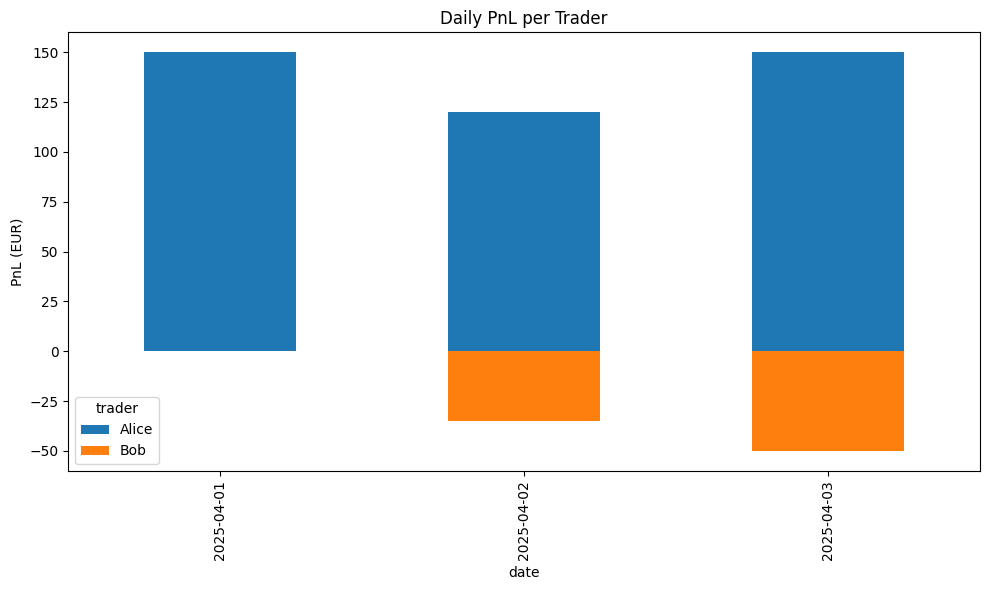

In [21]:
# Plot PnL per day per trader
pivot_df = daily_pnl.pivot(index='date', columns='trader', values='PnL')
pivot_df.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Daily PnL per Trader')
plt.ylabel('PnL (EUR)')
plt.tight_layout()
plt.savefig('daily_pnl.png')

In [22]:
pivot_df

trader,Alice,Bob
date,,
2025-04-01,150.0,0.0
2025-04-02,120.0,-35.0
2025-04-03,150.0,-50.0


In [24]:
# Export to Excel
%pip install openpyxl
with pd.ExcelWriter('trade_pnl_report.xlsx') as writer:
    df.to_excel(writer, sheet_name='All Trades with PnL', index=False)
    daily_pnl.to_excel(writer, sheet_name='Daily Summary', index=False)

Note: you may need to restart the kernel to use updated packages.
